In this notebook, you will learn how to fit probability distribution functions to synthetic spike trains.

In [76]:
import numpy as np
from matplotlib import pyplot as plt

For this demo, we will simulate spike trains with known parameters and then try to fit a model to the simulated data. This will allow us to compare the best-fit model parameters to real parameters and validate our approach.

In [77]:
# When testing models always use synthetic data first to make sure the code works as inteneded.
#  real parameters
lambda_true = 5     # spikes per second

# simulate spike train
T = 100             # total duration (seconds)
t_spike = []
t = 0

while t < T:
    isi = np.random.exponential(1 / lambda_true)  # exponential waiting time. Poisson spike train 5 spikes a second is the same as 1/5 seconds between spikes on average.
    t += isi
    if t < T:
        t_spike.append(t)

t_spike = np.array(t_spike) #Append doesn't work on numpy arrays, so we have to convert the list to a numpy array after the loop.

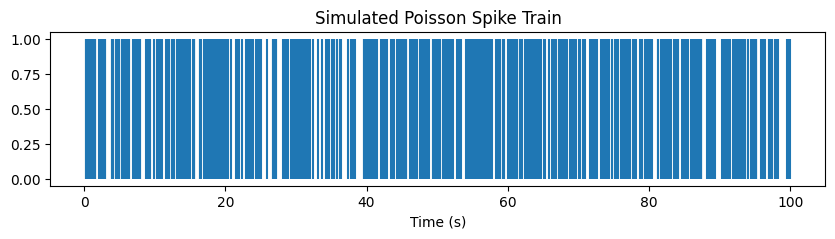

In [78]:
# plot spike raster
plt.figure(figsize=(10,2))
plt.vlines(t_spike, 0, 1)
plt.xlabel('Time (s)')
#plt.xlim(20,30) # zoom in to see the spikes better
plt.title('Simulated Poisson Spike Train')
plt.show()

Let us take a look at the probability distribution over spike counts. First, we define time bin edges and count the number of spikes within each time bin.

In [79]:
# parameters
T = 100
bin_size = 1 #100, 1 second bins

# define time bin edges
bins = np.arange(0, T + bin_size, bin_size) #Find a bin size and then define the bin edges. We want to go from 0 to T, but we need to add an extra bin edge at the end to include the last bin.

# spike counts per time bin
counts, _ = np.histogram(t_spike, bins=bins) #How many spikes fall between each edge of the bins? This gives us the spike count in each bin.

Now we need to count the number of instances of each value that spike counts assumes.

In [80]:
# empirical probability distribution of spike counts
freq = np.bincount(counts)
prob = freq / len(counts)
spike_counts = np.arange(len(freq))

Let's plot the result.

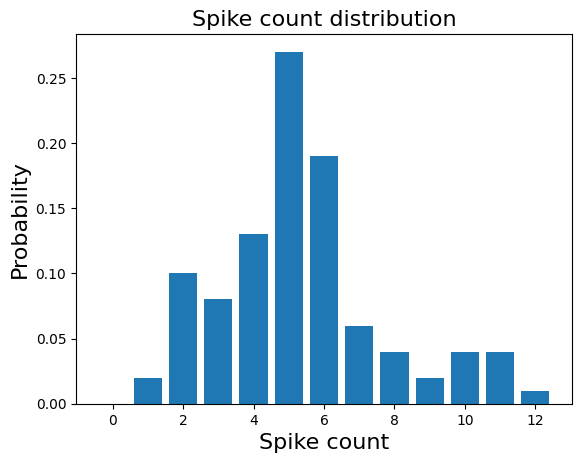

In [81]:
# plot
plt.figure()
plt.bar(spike_counts, prob, width=0.8)
plt.xlabel('Spike count', fontsize=16)
plt.ylabel('Probability', fontsize=16)
plt.title('Spike count distribution', fontsize=16)
plt.show()

#P(x)= [e^(-lambda) * lambda ^(x)] / (x!)

Let's overlay a theoretical poisson probability function with parameter $\lambda$ and see if we can visually get it to match the empirical distribution.

In [82]:
from math import factorial
import ipywidgets as widgets
from ipywidgets import interact

def poisson_pmf(k, lam):
    return np.exp(-lam) * (lam ** k) / np.array([factorial(int(kk)) for kk in k], dtype=float)

@interact(lam=widgets.FloatSlider(value=2, min=0.1, max=20, step=0.1, description='λ'))
def plot_poisson_overlay(lam):
    plt.figure()
    plt.bar(spike_counts, prob, width=0.8, alpha=0.6, label='Empirical')
    plt.plot(spike_counts, poisson_pmf(spike_counts, lam), 'o-', label='Poisson')
    plt.xlabel('Spike count')
    plt.ylabel('Probability')
    plt.title('Spike count distribution')
    plt.legend()
    plt.show()

interactive(children=(FloatSlider(value=2.0, description='λ', max=20.0, min=0.1), Output()), _dom_classes=('wi…

Tinkering with the curve to manually align it to with data is cumbersome. We can use optimization tools to identify the best parameter! A straightforward way to do it is to define a function that needs to be minimized and then pass that function to `minimize` which is available in the `scipy` library.

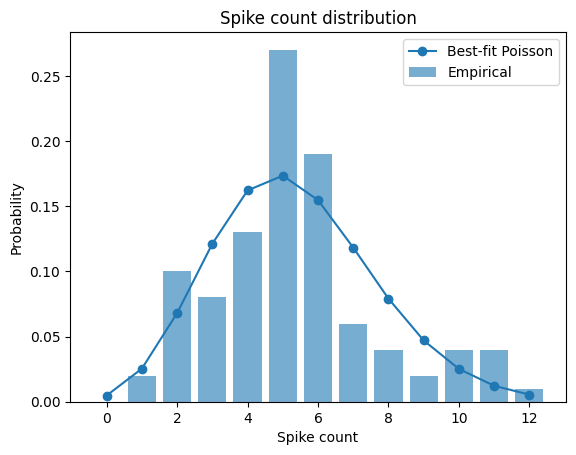

In [83]:
from scipy.optimize import minimize
import math

# counts needs to contain the data i.e., spike counts per 1 s bin
def neg_log_likelihood(lam, counts):
    logL = 0
    for k in counts:
        logL += k*np.log(lam) - lam - np.log(math.factorial(int(k)))
    return -logL

# initial guess
lam0 = 1
# optimize
result = minimize(neg_log_likelihood, lam0, args=(counts,))
lam_hat = result.x

# theoretical Poisson PMF using fitted λ
poisson = []
for ki in spike_counts:
    poisson.append(np.exp(-lam_hat) * lam_hat**ki / math.factorial(int(ki)))

# plot
plt.figure()
plt.bar(spike_counts, prob, width=0.8, alpha=0.6, label='Empirical')
plt.plot(spike_counts, poisson, 'o-', label='Best-fit Poisson')
plt.xlabel('Spike count')
plt.ylabel('Probability')
plt.title('Spike count distribution')
plt.legend()
plt.show()

That's it! Now let us take a look at the inter-spike interval distribution.

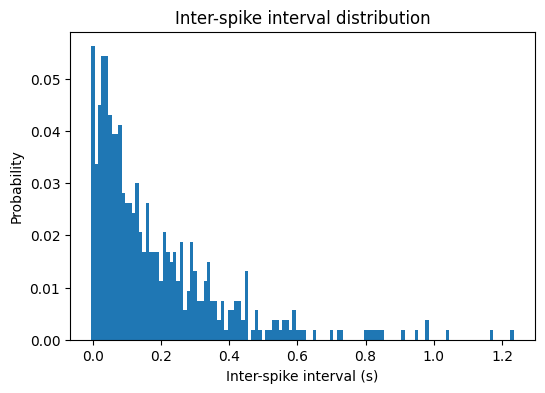

In [84]:
# compute inter-spike intervals
isi = np.diff(t_spike)

# choose bin width for inter-spike intervals
bin_width = 0.01  # 10 ms

# convert inter-spike intervals into integer bin indices
isi_bins = (isi / bin_width).astype(int)

# count occurrences
freq = np.bincount(isi_bins)
prob = freq / len(isi_bins)
t = np.arange(len(freq)) * bin_width  # convert bin index back to time

# plot
plt.figure(figsize=(6,4))
plt.bar(t, prob, width=bin_width)
plt.xlabel('Inter-spike interval (s)')
plt.ylabel('Probability')
plt.title('Inter-spike interval distribution')
plt.show()

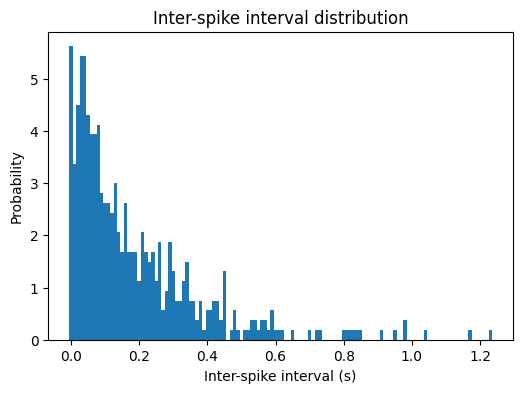

In [85]:
# convert to probability density
prob = prob / bin_width
# plot
plt.figure(figsize=(6,4))
plt.bar(t, prob, width=bin_width)
plt.xlabel('Inter-spike interval (s)')
plt.ylabel('Probability')
plt.title('Inter-spike interval distribution')
plt.show()

Let's overlay a theoretical exponential distribution.

In [86]:
@interact(lam=widgets.FloatSlider(value=3, min=0.1, max=20, step=0.1, description='λ'))
def plot_exp_overlay(lam):

    # exponential pdf
    pdf = lam * np.exp(-lam * t)

    plt.figure(figsize=(6,4))
    plt.bar(t, prob, width=bin_width, alpha=0.6, label='Empirical')
    plt.plot(t, pdf, label='Exponential')

    plt.xlabel('Inter-spike interval (s)')
    plt.ylabel('Probability density')
    plt.title('Inter-spike interval distribution')
    plt.legend()
    plt.show()

interactive(children=(FloatSlider(value=3.0, description='λ', max=20.0, min=0.1), Output()), _dom_classes=('wi…

Let's try optimizing instead.

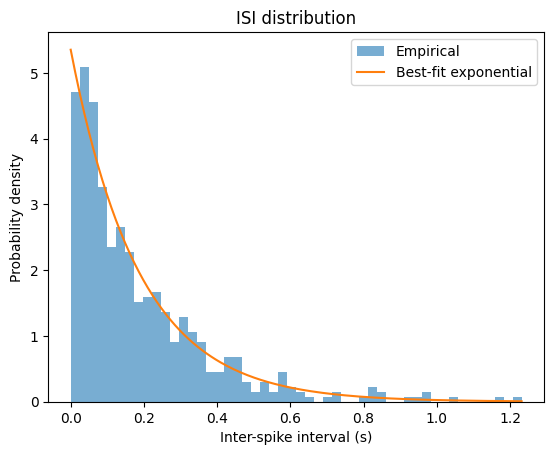

In [87]:
# isi needs to contain the data i.e., inter-spike intervals (in seconds)
isi = np.diff(t_spike)

def neg_log_likelihood(lam, isi):
    if lam <= 0: return np.inf    # exponential rate must be positive
    logL = 0
    for t in isi:
        logL += np.log(lam) - lam * t
    return -logL

# initial guess
lam0 = 1

# optimize
result = minimize(neg_log_likelihood, [lam0], args=(isi,))
lam_hat = result.x

# theoretical exponential curve
t = np.linspace(0, isi.max(), 200)
pdf = lam_hat * np.exp(-lam_hat * t)

# plot
plt.figure()
plt.hist(isi, bins=50, density=True, alpha=0.6, label='Empirical')
plt.plot(t, pdf, label='Best-fit exponential')
plt.xlabel('Inter-spike interval (s)')
plt.ylabel('Probability density')
plt.title('ISI distribution')
plt.legend()
plt.show()